# Obtención de datos: PaySim
Descarga y carga del dataset principal (PaySim) desde Kaggle.

In [4]:
!pip install -q kagglehub

In [5]:
import kagglehub

path = kagglehub.dataset_download("ealaxi/paysim1")

Using Colab cache for faster access to the 'paysim1' dataset.


In [6]:
import pandas as pd
import os

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Componente 1: construcción de secuencias por entidad

In [7]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [8]:
vc_orig = df["nameOrig"].value_counts()
vc_dest = df["nameDest"].value_counts()
print("nameOrig: max repeticiones =", vc_orig.max(), ", entidades con >1 tx =", (vc_orig > 1).sum())
print("nameDest: max repeticiones =", vc_dest.max(), ", entidades con >1 tx =", (vc_dest > 1).sum())


nameOrig: max repeticiones = 3 , entidades con >1 tx = 9298
nameDest: max repeticiones = 113 , entidades con >1 tx = 459658


In [9]:
MIN_TX = 3
MAX_SEQ_LEN = 50

entity_counts = df["nameDest"].value_counts()
valid_entities = entity_counts[entity_counts >= MIN_TX].index
df_valid = df[df["nameDest"].isin(valid_entities)].copy()
print("Entidades con más o igual a ", MIN_TX, "transacciones:", df_valid["nameDest"].nunique())


Entidades con más o igual a  3 transacciones: 382604


In [10]:
entity_labels = df_valid.groupby("nameDest")["isFraud"].max()
pos_entities = entity_labels[entity_labels == 1].index
neg_entities = entity_labels[entity_labels == 0].index

rng = np.random.default_rng(42)
NEG_PER_POS = 10
n_neg = min(len(neg_entities), len(pos_entities) * NEG_PER_POS)
neg_sample = rng.choice(neg_entities, size=n_neg, replace=False)

sampled_entities = list(pos_entities) + list(neg_sample)
df_sampled = df_valid[df_valid["nameDest"].isin(sampled_entities)].copy()
print("Entidades positivas:", len(pos_entities), ". Negativas muestreadas:", len(neg_sample))
print("Transacciones totales del subconjunto:", len(df_sampled))


Entidades positivas: 4747 . Negativas muestreadas: 47470
Transacciones totales del subconjunto: 549197


In [11]:
df_sampled = df_sampled.sort_values(["nameDest", "step"]).reset_index(drop=True)

TYPE_CATEGORIES = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]
type_dummies = df_sampled["type"].apply(lambda t: [1.0 if t == c else 0.0 for c in TYPE_CATEGORIES])
type_matrix = np.array(type_dummies.tolist())

hour = (df_sampled["step"] % 24).to_numpy()
hour_sin = np.sin(2 * np.pi * hour / 24)
hour_cos = np.cos(2 * np.pi * hour / 24)

log_amount = np.log1p(df_sampled["amount"].to_numpy())
log_oldbalorg = np.log1p(df_sampled["oldbalanceOrg"].to_numpy())
log_newbalorg = np.log1p(df_sampled["newbalanceOrig"].to_numpy())
log_oldbaldest = np.log1p(df_sampled["oldbalanceDest"].to_numpy())
log_newbaldest = np.log1p(df_sampled["newbalanceDest"].to_numpy())

raw_features = np.column_stack([
    log_amount, log_oldbalorg, log_newbalorg, log_oldbaldest, log_newbaldest,
    hour_sin, hour_cos, type_matrix,
])
FEATURE_NAMES = ["log_amount", "log_oldbalanceOrg", "log_newbalanceOrig",
                  "log_oldbalanceDest", "log_newbalanceDest", "hour_sin", "hour_cos"] + TYPE_CATEGORIES
print("Shape de features por transacción:", raw_features.shape)


Shape de features por transacción: (549197, 12)


In [12]:
entity_ids = np.array(df_sampled["nameDest"].unique(), dtype=object)
labels = entity_labels.loc[entity_ids].to_numpy()

train_ids, temp_ids, train_y, temp_y = train_test_split(
    entity_ids, labels, test_size=0.30, stratify=labels, random_state=42)
val_ids, test_ids, val_y, test_y = train_test_split(
    temp_ids, temp_y, test_size=0.50, stratify=temp_y, random_state=42)

split_map = {}
for eid in train_ids: split_map[eid] = "train"
for eid in val_ids: split_map[eid] = "val"
for eid in test_ids: split_map[eid] = "test"
df_sampled["split"] = df_sampled["nameDest"].map(split_map)
print({s: (df_sampled["split"] == s).sum() for s in ["train", "val", "test"]})


{'train': np.int64(385058), 'val': np.int64(81600), 'test': np.int64(82539)}


In [13]:
train_mask = (df_sampled["split"] == "train").to_numpy()
scaler = StandardScaler()
cont_cols = slice(0, 7)
scaler.fit(raw_features[train_mask][:, cont_cols])

norm_features = raw_features.copy()
norm_features[:, cont_cols] = scaler.transform(raw_features[:, cont_cols])


In [14]:
N_FEATURES = norm_features.shape[1]
sequences = np.zeros((len(entity_ids), MAX_SEQ_LEN, N_FEATURES), dtype="float32")
seq_lengths = np.zeros(len(entity_ids), dtype="int32")

entity_to_idx = {eid: i for i, eid in enumerate(entity_ids)}
row_entity = df_sampled["nameDest"].to_numpy()

per_entity_rows = {}
for row_idx, eid in enumerate(row_entity):
    per_entity_rows.setdefault(eid, []).append(row_idx)

for eid, rows in per_entity_rows.items():
    i = entity_to_idx[eid]
    L = min(len(rows), MAX_SEQ_LEN)
    seq_lengths[i] = L
    sequences[i, :L, :] = norm_features[rows[:L]]

print("Shape de secuencias:", sequences.shape)


Shape de secuencias: (52217, 50, 12)


In [15]:
entity_split = df_sampled.drop_duplicates("nameDest").set_index("nameDest")["split"]
meta = pd.DataFrame({
    "entity_id": entity_ids,
    "label": labels,
    "split": entity_split.loc[entity_ids].to_numpy(),
    "seq_len": seq_lengths,
})
meta.to_csv("C1_output_meta.csv", index=False)
np.save("C1_output_sequences.npy", sequences)
with open("C1_output_feature_names.json", "w") as f:
    json.dump(FEATURE_NAMES, f)
meta.head()


,entity_id,label,split,seq_len
0,C1000004082,0,train,6
1,C1000015936,0,train,16
2,C1000026379,0,val,4
3,C1000039615,1,train,3
4,C1000070008,0,train,12


### Verificación

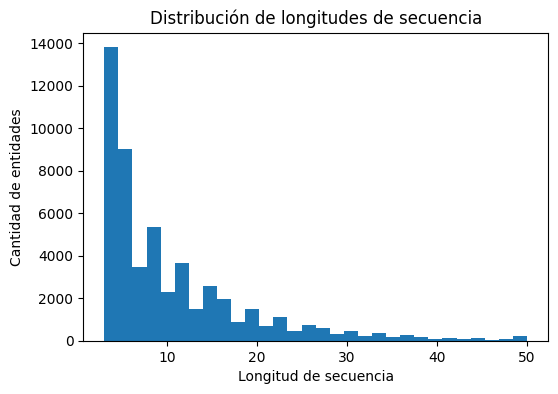

In [16]:
plt.figure(figsize=(6, 4))
plt.hist(meta["seq_len"], bins=30)
plt.xlabel("Longitud de secuencia")
plt.ylabel("Cantidad de entidades")
plt.title("Distribución de longitudes de secuencia")
plt.show()


Proporción de clases (0=normal, 1=sospechoso):
label
0    0.909091
1    0.090909
Name: proportion, dtype: float64


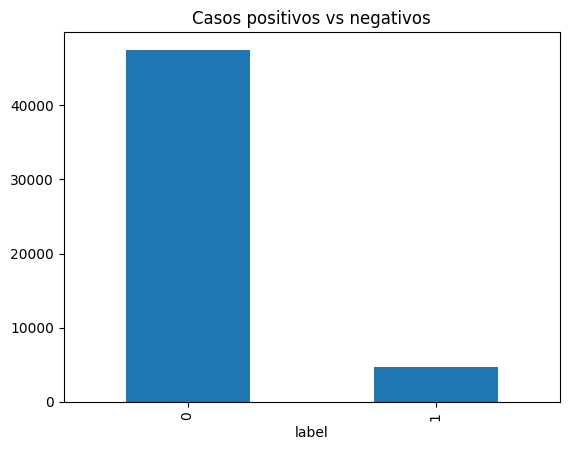

In [17]:
prop = meta["label"].value_counts(normalize=True)
print("Proporción de clases (0=normal, 1=sospechoso):")
print(prop)
meta["label"].value_counts().plot(kind="bar", title="Casos positivos vs negativos")
plt.show()


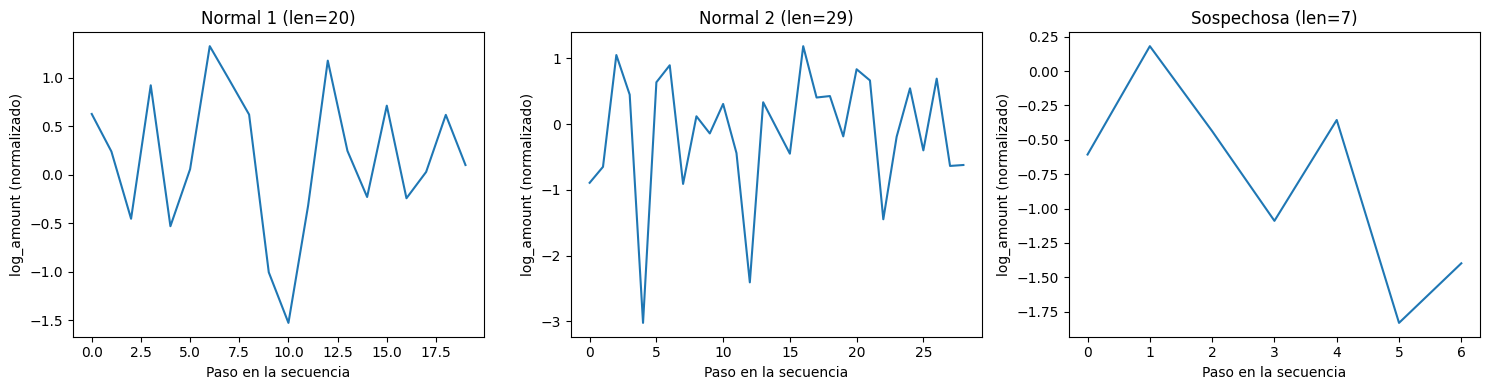

In [18]:
normal_idx = meta[meta["label"] == 0].sample(2, random_state=1).index
fraud_idx = meta[meta["label"] == 1].sample(1, random_state=1).index
example_idx = list(normal_idx) + list(fraud_idx)
example_titles = ["Normal 1", "Normal 2", "Sospechosa"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx, title in zip(axes, example_idx, example_titles):
    L = seq_lengths[idx]
    ax.plot(sequences[idx, :L, 0])  # log_amount normalizado
    ax.set_title(f"{title} (len={L})")
    ax.set_xlabel("Paso en la secuencia")
    ax.set_ylabel("log_amount (normalizado)")
plt.tight_layout()
plt.show()
